### Train/Test EDA

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
import seaborn as sns
from prompt_toolkit.cache import FastDictCache
from sympy.geometry.entity import rotate

In [3]:
# SibSp - число братьев сестер и супргугов на борту
# Parch - число родителей и детей на борту
# Fare - стоимость билета
# Ticket - номер билета
# Cabin - номер каюты
# Embarked - порт посадки на корабль
# Pclass - класс билета пассажира
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")
raw_train = train.copy()
raw_test = test.copy()

cols = [col for col in train.columns if col != 'Survived'] + ['Survived']
train = train[cols]

In [4]:
print(f'Training samples: {train.shape[0]}')
print(f'Test samples: {test.shape[0]}')
print(f'Train features: {train.shape[1]}')
print(f'Test features: {test.shape[1]}')

Training samples: 891
Test samples: 418
Train features: 12
Test features: 11


In [5]:
train.dtypes

PassengerId      int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
Survived         int64
dtype: object

In [6]:
train.memory_usage(deep=True) / 1024

Index           0.128906
PassengerId     6.960938
Pclass          6.960938
Name           73.059570
Sex            53.690430
Age             6.960938
SibSp           6.960938
Parch           6.960938
Ticket         55.470703
Fare            6.960938
Cabin          33.539062
Embarked       50.416016
Survived        6.960938
dtype: float64

In [7]:
display(train.head(5))
train.info()


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Pclass       891 non-null    int64  
 2   Name         891 non-null    str    
 3   Sex          891 non-null    str    
 4   Age          714 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Ticket       891 non-null    str    
 8   Fare         891 non-null    float64
 9   Cabin        204 non-null    str    
 10  Embarked     889 non-null    str    
 11  Survived     891 non-null    int64  
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [8]:
display(test.head(5))
test.info()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB


In [9]:
train.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare,Survived
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,2.308642,29.699118,0.523008,0.381594,32.204208,0.383838
std,257.353842,0.836071,14.526497,1.102743,0.806057,49.693429,0.486592
min,1.000000,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000
25%,223.500000,2.000000,20.125000,0.000000,0.000000,7.910400,0.000000
50%,446.000000,3.000000,28.000000,0.000000,0.000000,14.454200,0.000000
75%,668.500000,3.000000,38.000000,1.000000,0.000000,31.000000,1.000000
max,891.000000,3.000000,80.000000,8.000000,6.000000,512.329200,1.000000


### Есть пропущенные значения по некоторым столбцам. Большинство пассажиров - мужчины. Среди всех пассажиров выжило ~38%

In [10]:
pd.DataFrame({
    'train' : train.isna().sum(),
    'test' : test.isna().sum()
})

,train,test
Age,177,86.0
Cabin,687,327.0
Embarked,2,0.0
Fare,0,1.0
Name,0,0.0
Parch,0,0.0
PassengerId,0,0.0
Pclass,0,0.0
Sex,0,0.0
SibSp,0,0.0


### В Age, Cabin, Embarked, Fare(test) есть пропущенные значения

In [11]:
pd.DataFrame({
    'train' : train.nunique(),
    'test' : test.nunique()
})


,train,test
Age,88,79.0
Cabin,147,76.0
Embarked,3,3.0
Fare,248,169.0
Name,891,418.0
Parch,7,8.0
PassengerId,891,418.0
Pclass,3,3.0
Sex,2,2.0
SibSp,7,7.0


### Константные признаки отсутствуют

In [36]:
print(train['PassengerId'].isin(test['PassengerId']).sum())
print(test['Ticket'].isin(train['Ticket']).sum())

0
152


### В train и test нет пассажиров с одинаковыми Id,
### Но в test есть 152 пассажира, чьи номера билетов встречаются в train

##### Кодируем female=0 male=1

In [13]:
train['Sex'] = train['Sex'].map({'male': 1, 'female': 0})
test['Sex'] = test['Sex'].map({'male': 1, 'female': 0})

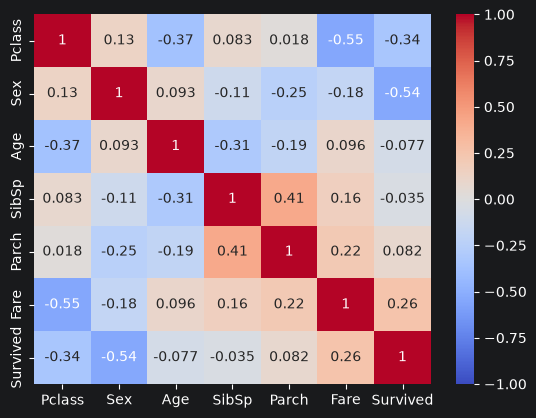

In [14]:
numerical = train.select_dtypes(include='number').drop(columns='PassengerId')
sns.heatmap(numerical.corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1, center = 0)
plt.show()

### Больше всего Survived коррелирует с
Fare: 0.26 - пассажиры с более дорогими билетами выживали чаще <br>
Pclass: -0.34- пассажиры с более престижным номером класса выживали чаще (1 class > 2 class > 3 class) <br>
Sex: -0.54 - пассажиры женского пола выживали чаще

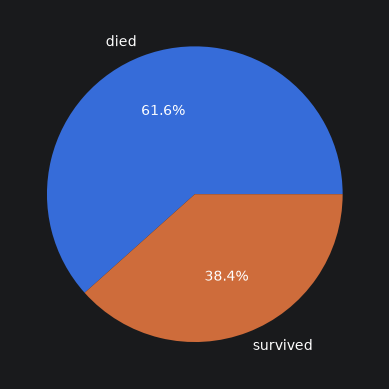

In [15]:
counts = train['Survived'].value_counts().sort_index()
plt.pie(counts,labels=['died','survived'],autopct='%.1f%%')
plt.show()

### Среди всех пассажиров выжили всего ~38.4%

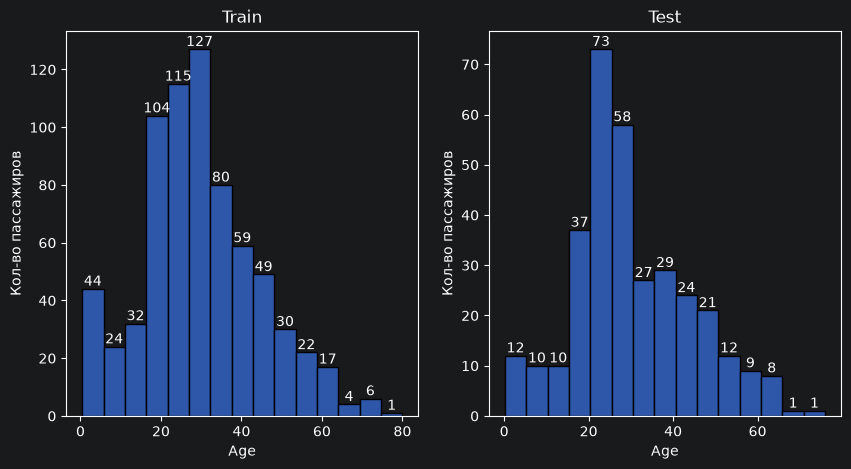

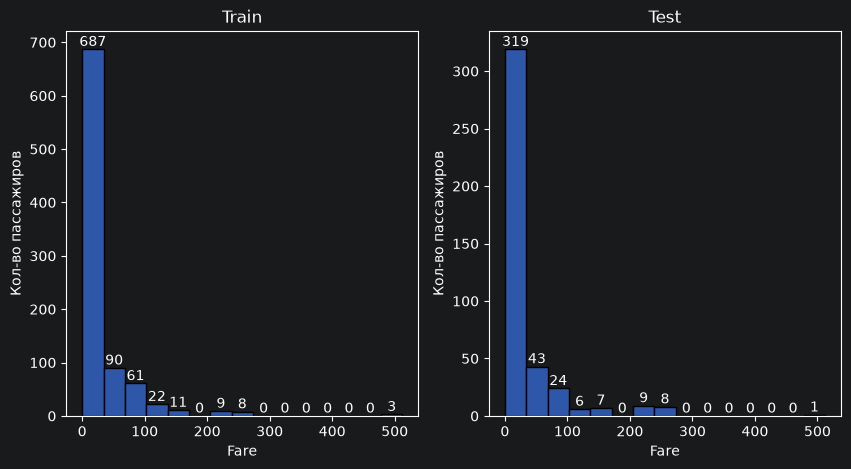

In [16]:
for col in ['Age','Fare']:
    fix, axes = plt.subplots(1,2, figsize=(10,5))
    for ax, df, title in zip(axes,[train,test],['Train','Test']):
        sns.histplot(df, x=df[col], bins=15, ax=ax)
        ax.bar_label(ax.containers[0],padding=0)
        ax.set_title(title)
        ax.set_ylabel('Кол-во пассажиров')
    plt.show()

### Судя по графикам распределения признаков 'Age' и 'Fare' очень похожи как в train, так и в test
### Распределение стоимости билетов неравномерное с длинным хвостом справа. Пассажиров с дорогостоящими билетами значительно меньше

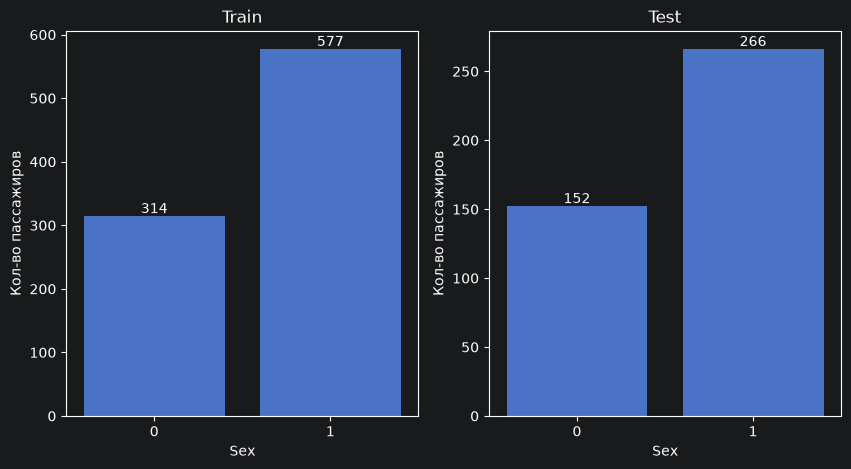

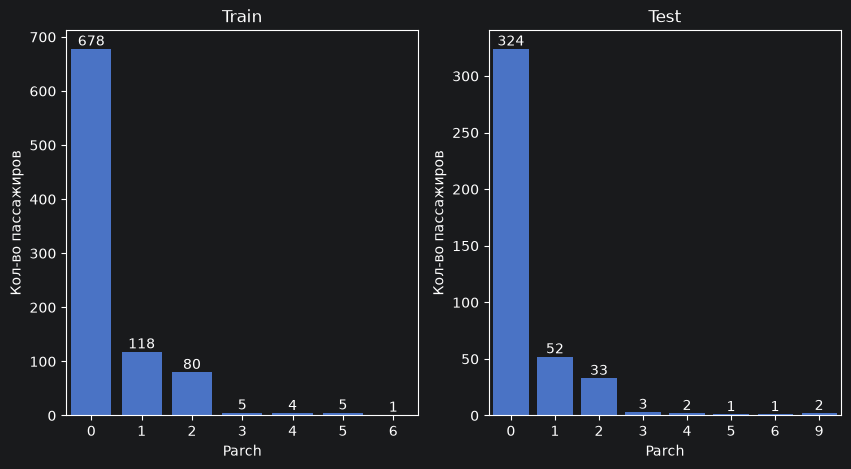

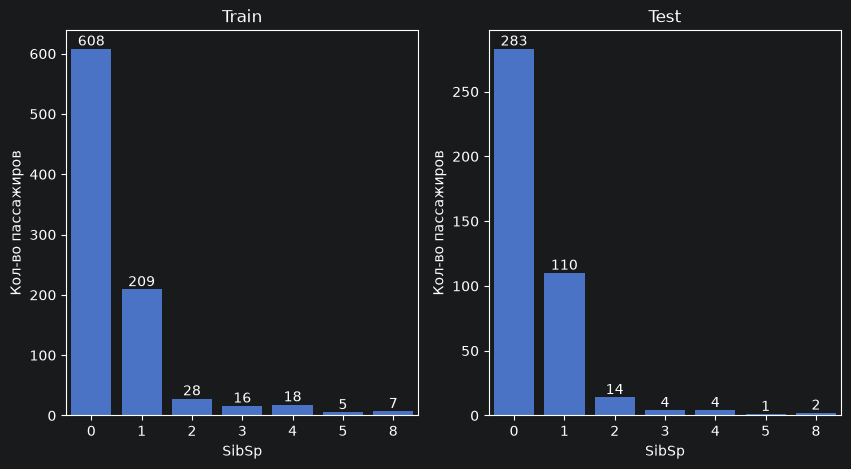

In [17]:
for col in ['Sex','Parch', 'SibSp']:
    fix, axes = plt.subplots(1,2, figsize=(10,5))
    for ax, df, title in zip(axes,[train,test],['Train','Test']):
        sns.countplot(df, x=df[col], ax=ax)
        ax.bar_label(ax.containers[0],padding=0)
        ax.set_title(title)
        ax.set_ylabel('Кол-во пассажиров')
    plt.show()

### Аналогичная ситуация с признаками 'Sex', 'Parch', 'SibSp'. Данные на трейн и на тест выборке в целом похожи по распределениям признаков
### Основные различия наблюдаются в редких значениях и в отдельных интервалах

In [18]:
age_bins = pd.cut(train['Age'], bins=range(0,91,10),right=False)
cnt = pd.crosstab(age_bins,train['Survived'])
cnt['% of survivors in a bin'] = cnt[1] / (cnt[0]+ cnt[1]) * 100
cnt

Survived,0,1,% of survivors in a bin
Age,,,
"[0, 10)",24,38,61.290323
"[10, 20)",61,41,40.196078
"[20, 30)",143,77,35.000000
"[30, 40)",94,73,43.712575
"[40, 50)",55,34,38.202247
"[50, 60)",28,20,41.666667
"[60, 70)",13,6,31.578947
"[70, 80)",6,0,0.000000
"[80, 90)",0,1,100.000000


## Таблица выживших/погибших по бинам 'Age'

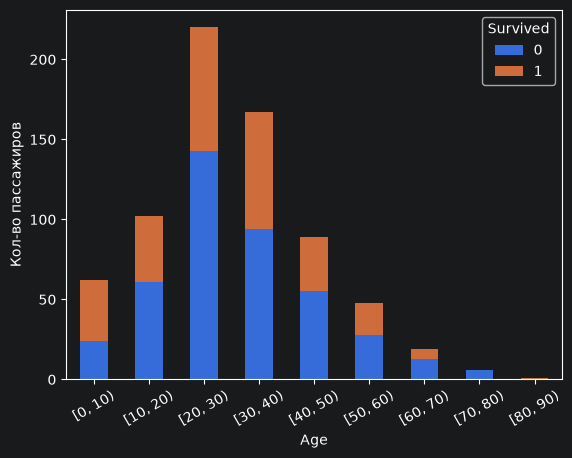

In [19]:
cnt.drop(columns='% of survivors in a bin').plot.bar(stacked=True)
plt.ylabel('Кол-во пассажиров')
plt.xticks(rotation=30)
plt.show()

### Большее число пассажиров находятся в возрасте от 20 до 40 лет, пожилых заметно меньше
### Доля выживших различается между возрастными группами.
до 10 лет - ~60% выжило <br>
10-60 лет - ~40% выжило <br>
60+ лет - ~27% выжило

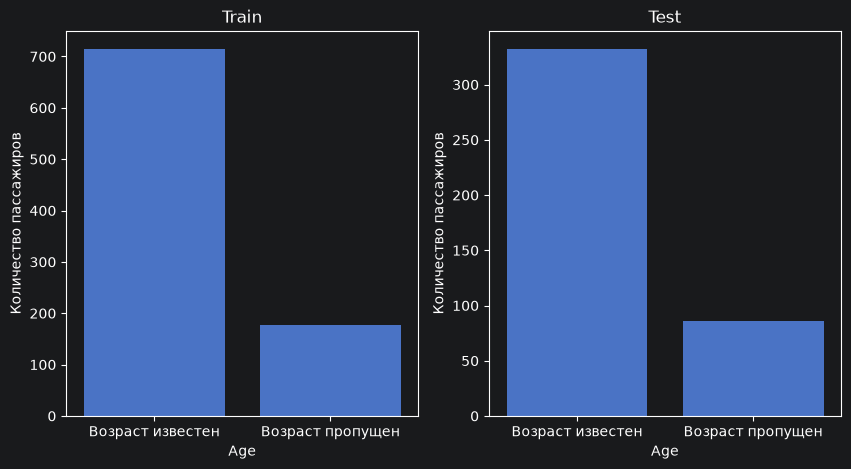

In [20]:
fig,axes = plt.subplots(1,2,figsize=(10,5))
for ax,df,title in zip(axes,[train,test],['Train','Test']):
    sns.countplot(x=df['Age'].isna(), order=[False, True],ax=ax)
    ax.set_xticks([0, 1], ['Возраст известен', 'Возраст пропущен'])
    ax.set_ylabel('Количество пассажиров')
    ax.set_title(title)
plt.show()

### В столбце с возастом 177 пропусков на трейне и 86 на тесте. Распределение схожее

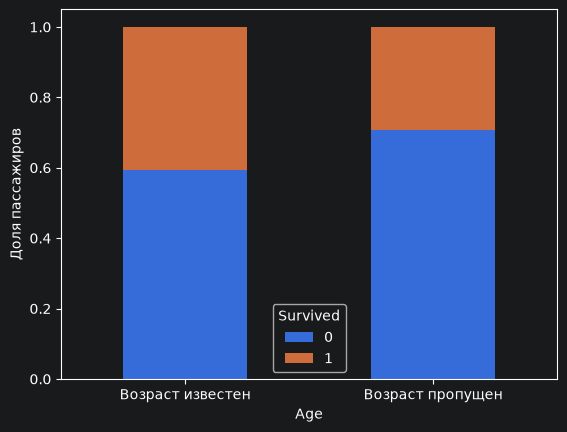

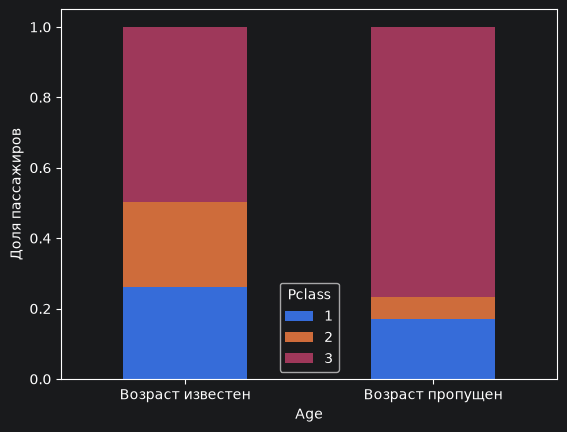

In [21]:
for col in ['Survived', 'Pclass']:
    counts = pd.crosstab(train['Age'].isna(), train[col], normalize='index')
    counts.plot.bar(stacked=True)
    plt.xticks([0, 1], ['Возраст известен', 'Возраст пропущен'],rotation=0)
    plt.ylabel('Доля пассажиров')
    plt.show()

### Пропуски в Age связаны с классом билета и выживаемостью пассажиров, они могут быть информативны. Строки с пропущенным возрастом не следует удалять, так как это приведет к потери информации

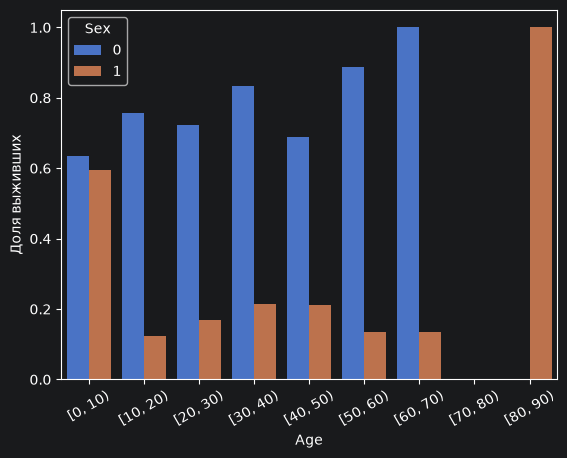

In [22]:
sns.barplot(data=train, x=age_bins, y='Survived', hue='Sex', errorbar=None)
plt.ylabel('Доля выживших')
plt.xticks(rotation=30)
plt.show()

### В возрастной группе 10-70 лет женщины выживают намного чаще мужчин, значит связь возраста с выживаемостью зависит от пола
### Среди детей до 10 лет доля выживших схожа по каждому полу
### По категории 70+ трудно сделать вывод из-за малого кол-ва пассажиров в ней

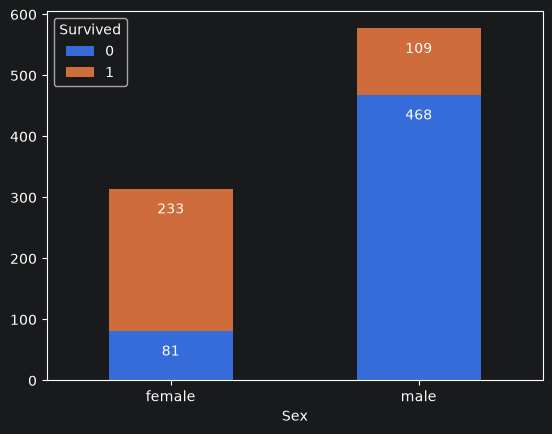

In [23]:
counts = pd.crosstab(train['Sex'], train['Survived'])
ax = counts.sort_index().plot.bar(stacked=True)
plt.xticks(ticks=[0,1], labels=['female', 'male'], rotation=0)
ax.bar_label(ax.containers[0], padding=-20)
ax.bar_label(ax.containers[1], padding=-20)
plt.show()

### Пассажиров мужского пола заметно больше
### Большинство пассажиров женского пола выжило, большинство пассажиров мужского пола погибло


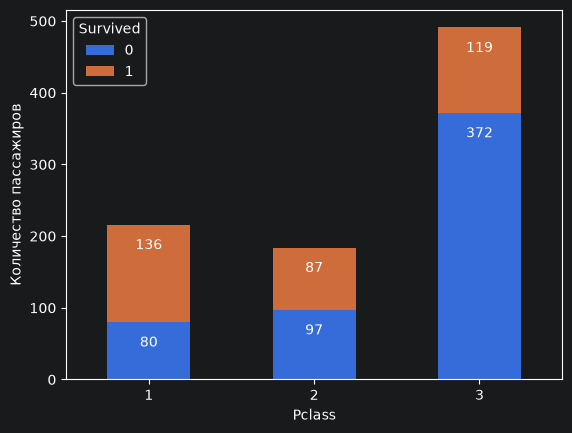

In [24]:
counts = pd.crosstab(train['Pclass'], train['Survived'])
ax = counts.sort_index().plot.bar(stacked=True)
ax.bar_label(ax.containers[0], padding=-20)
ax.bar_label(ax.containers[1], padding=-20)
plt.xticks(rotation=0)
plt.ylabel("Количество пассажиров")
plt.show()

### Большая часть пассажиров ехало 3 классом, меньшая часть - 1-ым и 2-ым классами
### Среди пассажиров, ехавших в 1 классе выжило большинство, во 2 классе - почти половина, в 3 классе - меньшинство

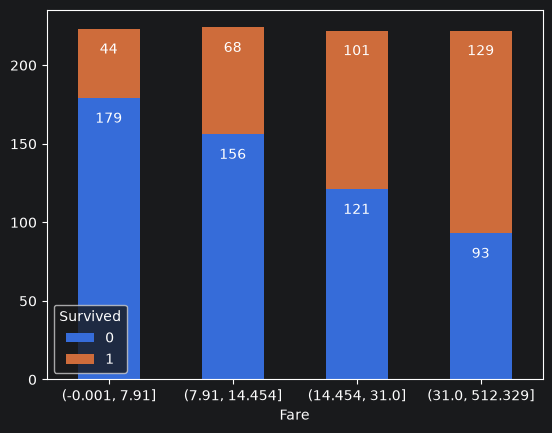

In [25]:
fare_groups = pd.qcut(train['Fare'],4)
counts = pd.crosstab(fare_groups, train['Survived'])
ax = counts.sort_index().plot.bar(stacked=True)
ax.bar_label(ax.containers[0], padding=-20)
ax.bar_label(ax.containers[1], padding=-20)
plt.xticks(rotation=0)
plt.show()

### Проведено разбиение по квантилям. Заметно, что пассажиры с более дорогими билетами выживали чаще

In [26]:
display(train[train['Fare'] < 3])
display(train[train['Fare'] > 300])

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
179,180,3,"Leonard, Mr. Lionel",1,36.0,0,0,LINE,0.0,NaN,S,0
263,264,1,"Harrison, Mr. William",1,40.0,0,0,112059,0.0,B94,S,0
271,272,3,"Tornquist, Mr. William Henry",1,25.0,0,0,LINE,0.0,NaN,S,1
277,278,2,"Parkes, Mr. Francis ""Frank""",1,NaN,0,0,239853,0.0,NaN,S,0
302,303,3,"Johnson, Mr. William Cahoone Jr",1,19.0,0,0,LINE,0.0,NaN,S,0
413,414,2,"Cunningham, Mr. Alfred Fleming",1,NaN,0,0,239853,0.0,NaN,S,0
466,467,2,"Campbell, Mr. William",1,NaN,0,0,239853,0.0,NaN,S,0
481,482,2,"Frost, Mr. Anthony Wood ""Archie""",1,NaN,0,0,239854,0.0,NaN,S,0
597,598,3,"Johnson, Mr. Alfred",1,49.0,0,0,LINE,0.0,NaN,S,0
633,634,1,"Parr, Mr. William Henry Marsh",1,NaN,0,0,112052,0.0,NaN,S,0


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
258,259,1,"Ward, Miss. Anna",0,35.0,0,0,PC 17755,512.3292,NaN,C,1
679,680,1,"Cardeza, Mr. Thomas Drake Martinez",1,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C,1
737,738,1,"Lesurer, Mr. Gustave J",1,35.0,0,0,PC 17755,512.3292,B101,C,1


### Встречаются пассажиры с нулевой стоимостью билетов, судя по открытым источникам это можно трактовать как служебный или комплиментарный проезд. Такие значения удалять не стоит
### Высокая стоимость также не является основанием для удаления. Стоит еще заметить, что у трех пассажиров из таблицы номер билета совпадает
### Возможно это общая стоимость билета, а не сумма, которую каждый заплатил отдельно

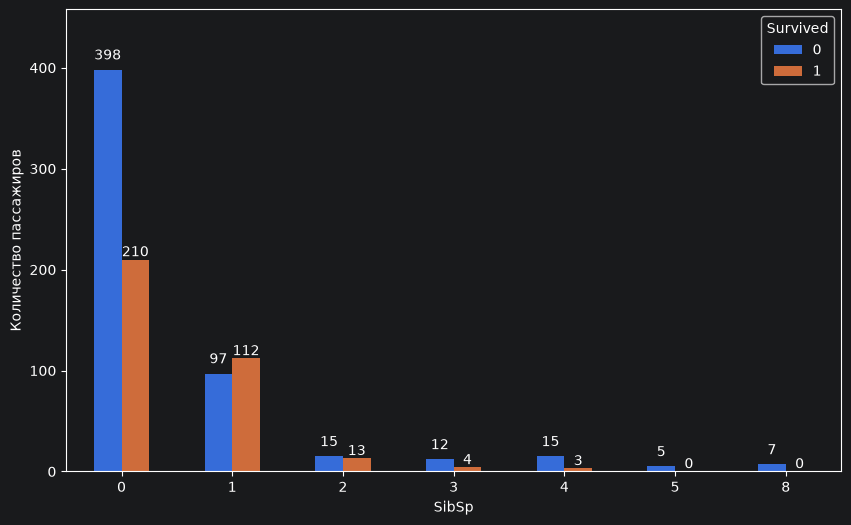

In [27]:
cnt = pd.crosstab(train['SibSp'], train['Survived'])
ax = cnt.sort_index().plot.bar(figsize=(10,6))
ax.margins(y = 0.15)
ax.bar_label(ax.containers[0], padding = 5)
ax.bar_label(ax.containers[1], padding = 0)
plt.xticks(rotation=0)
plt.ylabel("Количество пассажиров")
plt.show()

### Большинство пассажиров имеющий 1 брата/сестру или супругу на борту выжили. Пассажиры с большими значениями SibSp выживали гораздо реже

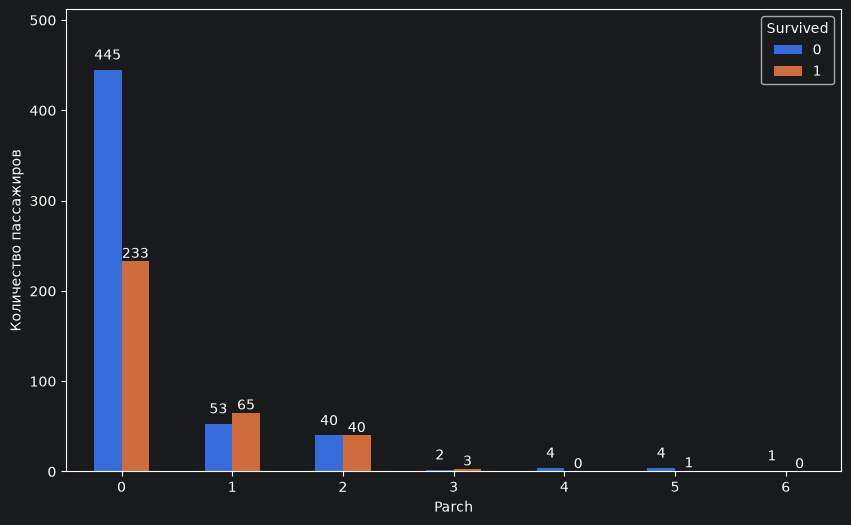

In [28]:
cnt = pd.crosstab(train['Parch'], train['Survived'])
ax = cnt.sort_index().plot.bar(figsize=(10,6))
ax.margins(y = 0.15)
ax.bar_label(ax.containers[0], padding = 5)
ax.bar_label(ax.containers[1], padding = 0)
plt.xticks(rotation=0)
plt.ylabel("Количество пассажиров")
plt.show()

### Похожее распределение и по признаку Parch - число родителей и детей на борту. Пассажиры с 1-2 родителями/детьми на борту выживали чаще


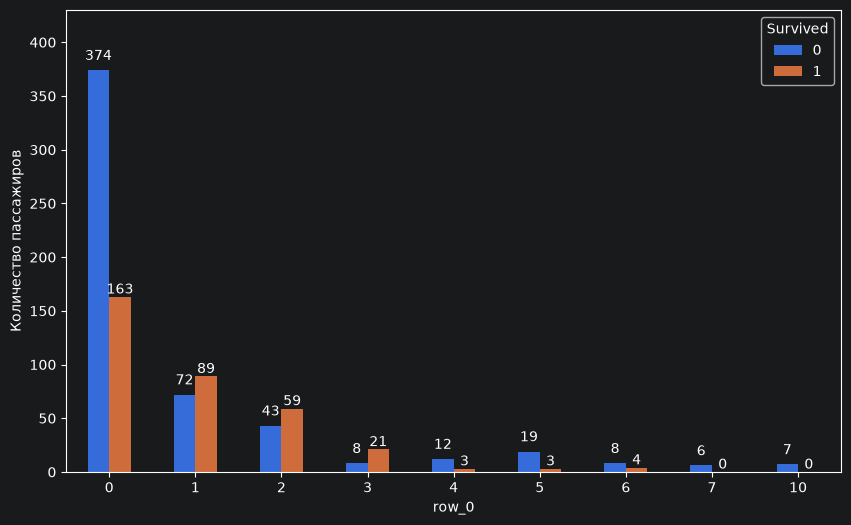

In [29]:
num_of_relatives = train['SibSp'] + train['Parch']
cnt = pd.crosstab(num_of_relatives, train['Survived'])
ax = cnt.sort_index().plot.bar(figsize=(10,6))
ax.margins(y = 0.15)
ax.bar_label(ax.containers[0], padding = 5)
ax.bar_label(ax.containers[1], padding = 0)
plt.xticks(rotation=0)
plt.ylabel("Количество пассажиров")
plt.show()

### Видно что люди, у которых на борту было от 1 до 3 родственников выживали гораздо чаще остальных

In [30]:
train[['Ticket','Cabin', 'Embarked']].nunique()

Ticket      681
Cabin       147
Embarked      3
dtype: int64

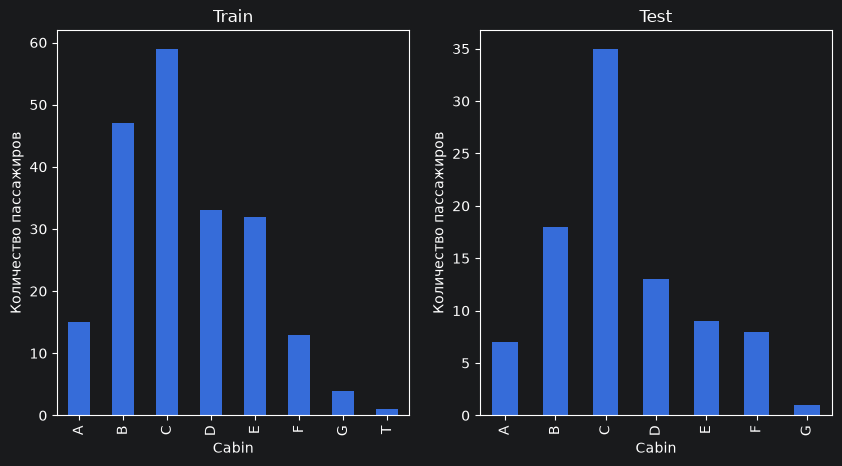

687


In [64]:
fig,ax = plt.subplots(1,2,figsize=(10,5))
for ax, df, title in zip(ax, [train,test], ['Train', 'Test']):
    df['Cabin'][df['Cabin'].notna()].str[0].value_counts().sort_index().plot.bar(ax=ax)
    ax.set_title(title)
    ax.set_ylabel('Количество пассажиров')
plt.show()
print(train['Cabin'].isna().sum())

### Столбец Embarked имеет всего 3 уникальных значения, столбец Cabin содержит букву и номер. Буквой обозначается каждая группа кают, всего таких групп 8
### Каюты групп B, C, D, E встречаются чаще остальных. 687 значений - NaN, это много
### Распределения на train и на test различаются, но не сильно. На test нет ни одного пассажира из кают группы T

In [32]:
train['Cabin_group'] = train['Cabin'][train['Cabin'].notna()].str[0]
train.loc[train['Cabin_group'].isna(), 'Cabin_group'] = 'U'

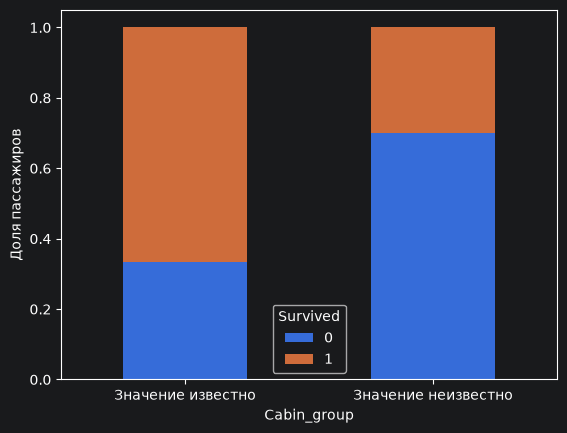

In [33]:
cnt = pd.crosstab(train['Cabin_group']=='U', train['Survived'], normalize='index')
cnt.sort_index().plot.bar(stacked=True)
plt.xticks([0,1],['Значение известно', 'Значение неизвестно'], rotation=0)
plt.ylabel('Доля пассажиров')
plt.show()

### Пассажиры с указанной группой кают выживали чаще. Пропущенные значения имеют информативность

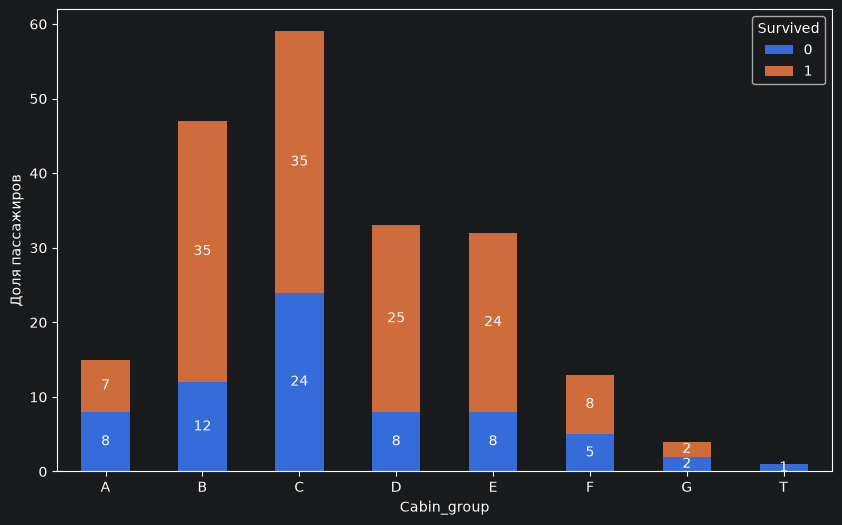

In [34]:
cnt = pd.crosstab(train.loc[train['Cabin_group'] != 'U', 'Cabin_group'], train['Survived'])
ax = cnt.sort_index().plot.bar(stacked=True, figsize=(10,6))
for cont, col in zip(ax.containers,cnt.columns):
    labels = [str(v) if v != 0 else '' for v in cnt[col]]
    ax.bar_label(cont, labels=labels, label_type='center')
plt.ylabel('Доля пассажиров')
plt.xticks(rotation=0)
plt.show()

### Пассажиры с Cabin равным B, C, D, E, F выживали значительно чаще пассажиров без указанной кабины или из оставшихся кабин
### В кабинах группы T и G слишком мало пассажиров

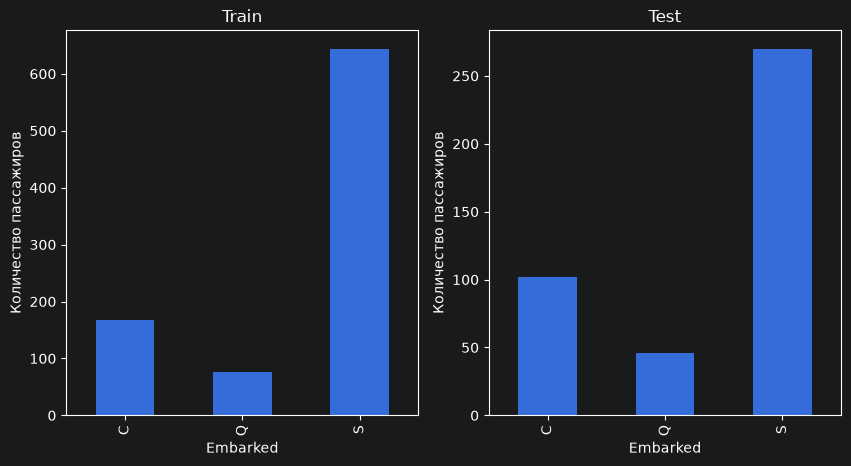

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived,Cabin_group
61,62,1,"Icard, Miss. Amelie",0,38.0,0,0,113572,80.0,B28,NaN,1,B
829,830,1,"Stone, Mrs. George Nelson (Martha Evelyn)",0,62.0,0,0,113572,80.0,B28,NaN,1,B


In [38]:
fig,ax = plt.subplots(1,2,figsize=(10,5))
for ax, df, label in zip(ax, [train,test], ['Train', 'Test']):
    df['Embarked'][df['Embarked'].notna()].str[0].value_counts().sort_index().plot.bar(ax=ax)
    ax.set_title(label)
    ax.set_ylabel('Количество пассажиров')
plt.show()
train[train['Embarked'].isna()]

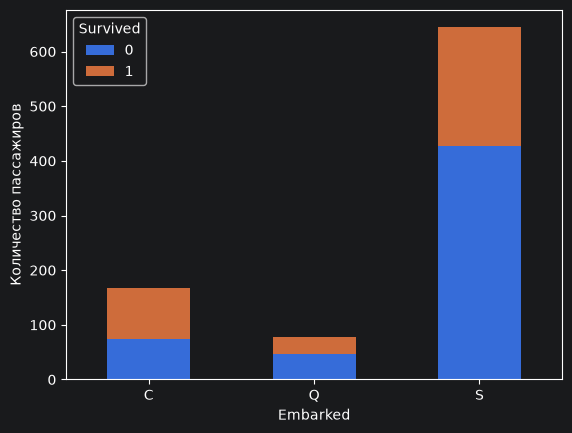

In [39]:
cnt = pd.crosstab(train.loc[train['Embarked'].notna(), 'Embarked'], train['Survived'])
cnt.sort_index().plot.bar(stacked=True)
plt.xticks(rotation=0)
plt.ylabel('Количество пассажиров')
plt.show()

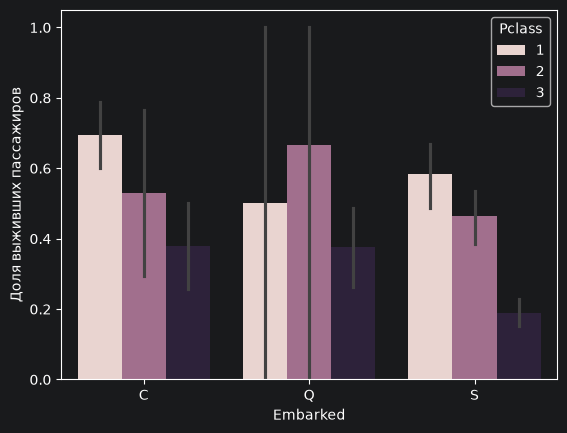

In [61]:
sns.barplot(train, x='Embarked', y='Survived', hue = 'Pclass', order=sorted(['C','Q','S']), )
plt.ylabel('Доля выживших пассажиров')
plt.show()

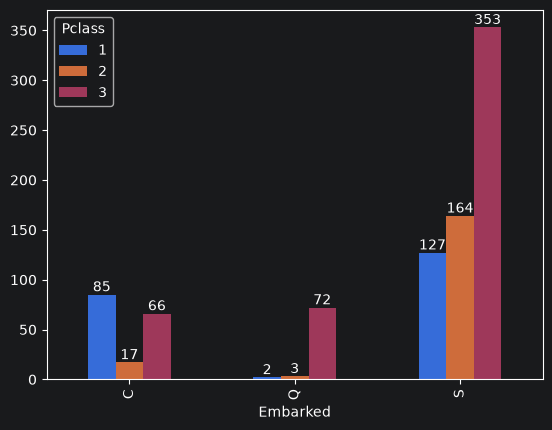

In [63]:
cnt = pd.crosstab(train['Embarked'],train['Pclass'])
ax = cnt.sort_index().plot.bar()
for i in range(3):
    ax.bar_label(ax.containers[i], padding = 0)
plt.show()

#### Заметно, что выживаемость различалась среди пассажиров севших в 3 разных портах.
#### Частично эта разница объясняется тем, что распределение пассажиров по Pclass в портах посадки отличалось.
#### Порт посадки связан с выживаемостью, но нельзя утверждать, что именно этот признак напрямую влияет на нее

## Обобщение
1) Трейн и тест данные имеют схожую природу
2) Наиболее заметное влияние на выживаемость оказывают признаки Sex, Age, Fare, Pclass. Но не стоит недооценивать остальные.
3) Пропуски в данных несут информацию и влияют на Survived.

### Дополнительные идеи
1) Признак Ticket имеет повторяющиеся значения; один и тот же номер билета может встречаться как в train, так и в test. Это может укзаывать на пассажиров, путешествовавших вместе.
2) В именах содержатся обращения к именам людей (Mr, Miss и т.д.), которые могут быть информативным признаком.